# RetinaMNIST Diabetic Retinopathy Classification

In [1]:
!pip install medmnist torchinfo coral-pytorch timm

## 1. Environment setup and fix random seed

In [2]:
import random
import numpy as np
import os
import hashlib
from matplotlib import pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2
import copy
import timm

import torch
from torch import nn
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torchinfo import summary
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, cohen_kappa_score, accuracy_score, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

from medmnist import RetinaMNIST

from coral_pytorch.layers import CoralLayer
from coral_pytorch.losses import coral_loss
from coral_pytorch.dataset import levels_from_labelbatch, proba_to_label


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PREPROCESSED_DIR = "/content/preprocessed"

set_seed(SEED)

## 2. Load the dataset

In [3]:
train_dataset = RetinaMNIST(split='train', download=True, size=224)
val_dataset = RetinaMNIST(split='val', download=True, size=224)
test_dataset = RetinaMNIST(split='test', download=True, size=224)

100%|██████████| 128M/128M [01:43<00:00, 1.24MB/s] 


## 3. Data exploration and preprocessing

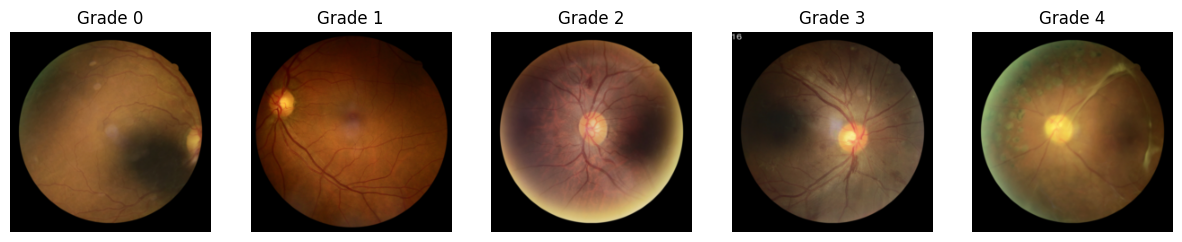

In [4]:
classes = np.unique(train_dataset.labels.flatten())

sample_images = []
for c in classes:
    labels_flat = train_dataset.labels.flatten()
    idx = np.where(labels_flat == c)[0][0]
    img_arr = np.squeeze(train_dataset.imgs[idx])
    sample_images.append(img_arr)

plt.figure(figsize=(15, 5))
for i, img_arr in enumerate(sample_images):
    plt.subplot(1, len(sample_images), i + 1)
    if img_arr.ndim == 3:
        plt.imshow(img_arr)
    else:
        plt.imshow(img_arr, cmap='gray')
    plt.title(f'Grade {int(classes[i])}')
    plt.axis('off')
plt.show()

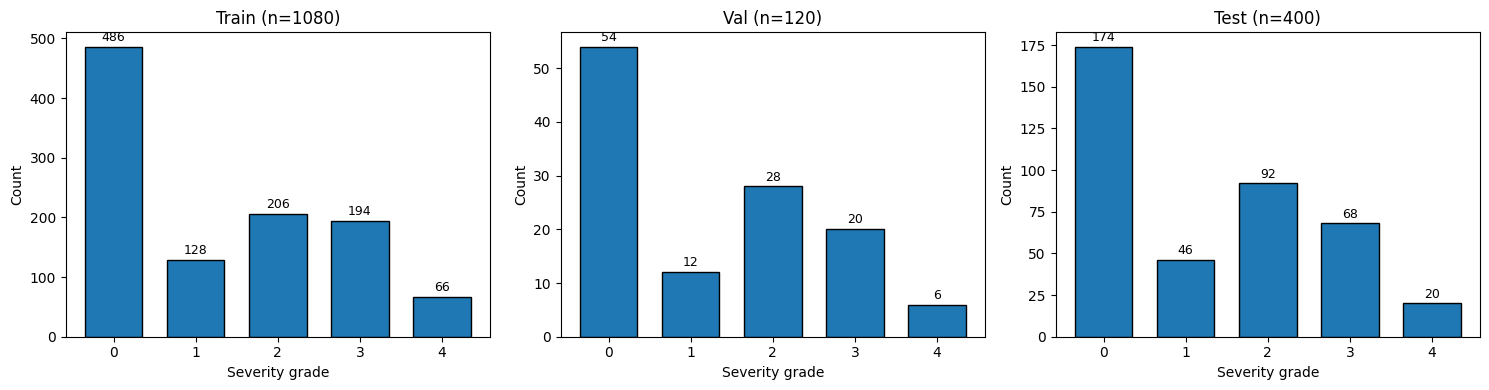

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split_name, dataset in zip(axes,
                                    ['Train', 'Val', 'Test'],
                                    [train_dataset, val_dataset, test_dataset]):
    labels = dataset.labels.flatten()
    counts = np.bincount(labels, minlength=len(classes))
    ax.bar(classes, counts, edgecolor='black', width=0.7)
    ax.set_xticks(classes)
    ax.set_title(f'{split_name} (n={len(labels)})')
    ax.set_xlabel('Severity grade')
    ax.set_ylabel('Count')
    for cls, cnt in zip(classes, counts):
        ax.text(cls, cnt + max(counts) * 0.01, str(cnt),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Check for data leakage across splits

Even if the dataset is well-maintained, we check for duplicates across splits to ensure that there is no data leakage. We compute the MD5 hash of each image and compare them across the training, validation, and test sets. Identical images will have the same hash, so if we find any matching hashes inside and across splits, it indicates that the same image appears multiple times in the same split or in multiple splits, which could lead to data leakage and biased evaluation results.

In [6]:
def md5_hash(img_arr):
    data = img_arr.tobytes()
    return hashlib.md5(data).hexdigest()

train_hashes = [md5_hash(train_dataset.imgs[i]) for i in range(len(train_dataset))]
val_hashes = [md5_hash(val_dataset.imgs[i])   for i in range(len(val_dataset))]
test_hashes = [md5_hash(test_dataset.imgs[i])  for i in range(len(test_dataset))]

train_set = set(train_hashes)
val_set = set(val_hashes)
test_set = set(test_hashes)

print(f"\nSplit sizes:\n\tTrain={len(train_hashes)}\n\tVal={len(val_hashes)}\n\tTest={len(test_hashes)}")
print(f"Unique:\n\tTrain={len(train_set)}\n\tVal={len(val_set)}\n\tTest={len(test_set)}")
print(f"\nIntersections (potential leakage):")
print(f"\tTrain ∩ Val: {len(train_set & val_set)}")
print(f"\tTrain ∩ Test: {len(train_set & test_set)}")
print(f"\tVal ∩ Test: {len(val_set & test_set)}")

for name, h_list in [('Train', train_hashes), ('Val', val_hashes), ('Test', test_hashes)]:
    dup = len(h_list) - len(set(h_list))
    if dup > 0:
        print(f"{name} has {dup} duplicate image(s) within the split")


Split sizes:
	Train=1080
	Val=120
	Test=400
Unique:
	Train=1080
	Val=120
	Test=400

Intersections (potential leakage):
	Train ∩ Val: 0
	Train ∩ Test: 0
	Val ∩ Test: 0


## 4. Preprocessing techniques for diabetic retinopathy

Implementing techniques from the literature:
- **Ben Graham**: Gaussian unsharp masking
- **Usuyama-style**: per-channel normalization

In [7]:
def preprocess_ben_graham(img: np.ndarray, img_size: int = 224, sigma: float = 5)  -> np.ndarray:
    """
    Ben Graham-style preprocessing: resize, apply Gaussian blur, and
    add a circular mask to focus on the central region of the image.
    
    Args:
        img (np.ndarray): Input image.
        img_size (int): Size to which the image is resized (default: 224)
        sigma (float): Standard deviation for Gaussian blur (default: 5)

    Returns:
        np.ndarray: Preprocessed image.

    Reference: used in Graham, B. (2015). Kaggle Diabetic Retinopathy Detection competition.
    """
    img = cv2.resize(img, (img_size, img_size))

    img = cv2.addWeighted(
        img, 4,
        cv2.GaussianBlur(img, (0, 0), sigma), -4,
        128
    )

    mask = np.zeros_like(img)
    h, w = img.shape[:2]
    cv2.circle(mask, (w // 2, h // 2), int(min(h, w) * 0.45), (1, 1, 1), -1)
    img = img * mask + 128 * (1 - mask)

    return np.clip(img, 0, 255).astype(np.uint8)

def preprocess_usuyama(img: np.ndarray, target_size: int = 224) -> np.ndarray:
    """
    Usuyama-style preprocessing: resize, per-channel z-score normalization, and rescale to [0, 255].

    Args:
        img (np.ndarray): Input image.
        target_size (int): Size to which the image is resized (default: 224)

    Returns:
        np.ndarray: Preprocessed image.

    Reference: used in Minarno et al., JOIV 2022
    """
    resized = cv2.resize(img, (target_size, target_size)).astype(np.float32)

    for ch in range(3):
        ch_data = resized[:, :, ch]
        m, s = ch_data.mean(), ch_data.std()
        if s > 0:
            resized[:, :, ch] = (ch_data - m) / s
        else:
            resized[:, :, ch] = ch_data - m

    resized = resized - resized.min()
    resized = (resized / (resized.max() + 1e-8) * 255).astype(np.uint8)

    # TODO: clahe(?)

    return resized

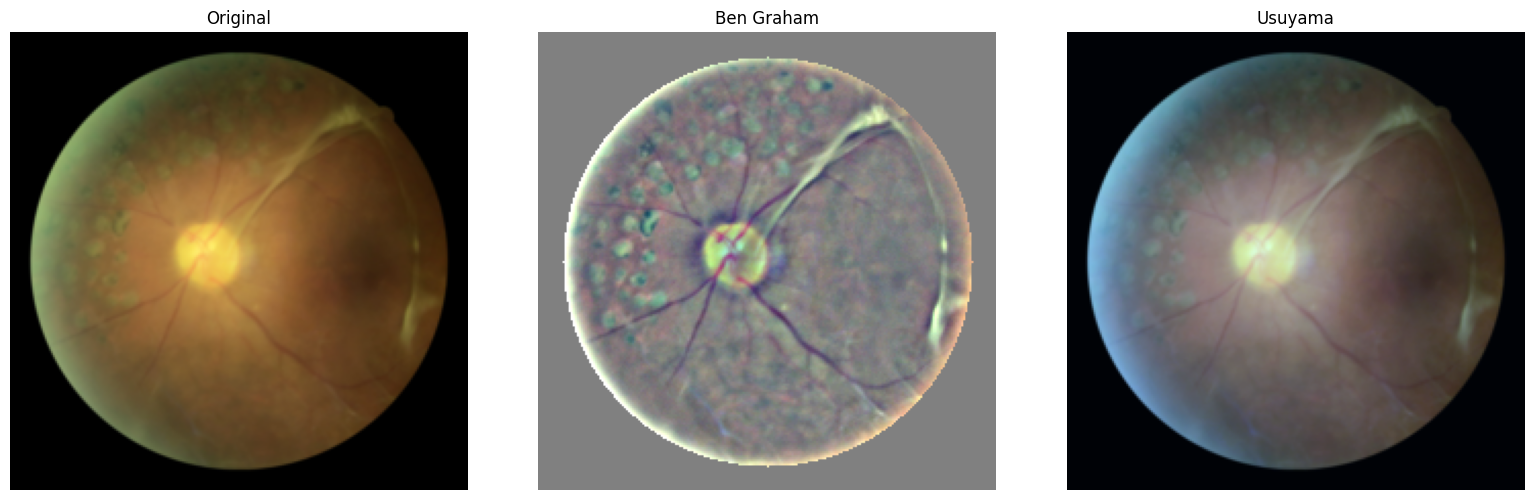

In [8]:
viz_class = 4

labels_flat = train_dataset.labels.flatten()
idx_sample = np.where(labels_flat == viz_class)[0][0]
sample = np.squeeze(train_dataset.imgs[idx_sample]).astype(np.uint8)

original = cv2.resize(sample, (224, 224))
bg = preprocess_ben_graham(sample, sigma=5)
usuyama = preprocess_usuyama(sample)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Original', 'Ben Graham', 'Usuyama']
for ax, img, title in zip(axes, [original, bg, usuyama], titles):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [9]:
splits = [
    ("train", train_dataset),
    ("val",   val_dataset),
    ("test",  test_dataset),
]

for split_name, dataset in splits:
    labels_flat = dataset.labels.flatten()
    class_counts: dict[int, int] = {}
    for i in tqdm(range(len(dataset)), desc=split_name):
        label = int(labels_flat[i])
        class_dir = os.path.join(PREPROCESSED_DIR, split_name, str(label))
        os.makedirs(class_dir, exist_ok=True)

        img = np.squeeze(dataset.imgs[i]).astype(np.uint8)
        proc = preprocess_ben_graham(img)
        # proc = preprocess_usuyama(img)
        # proc = img

        class_counts[label] = class_counts.get(label, 0) + 1
        fname = f"{class_counts[label]:05d}.png"
        Image.fromarray(proc).save(os.path.join(class_dir, fname))

print(f"Images saved under {PREPROCESSED_DIR}/")

test: 100%|██████████| 400/400 [00:10<00:00, 38.02it/s]

Images saved under /content/preprocessed/


In [10]:
def load_preprocessed(split_name: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Load saved preprocessed images and labels.
    
    Args:
        split_name (str): Name of the dataset split ('train', 'val', or 'test').
    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing:
            - imgs: A numpy array of shape (N, H, W, C) containing the preprocessed images.
            - labels: A numpy array of shape (N,) containing the corresponding labels for the images.
    """
    split_dir = os.path.join(PREPROCESSED_DIR, split_name)
    imgs, labels = [], []
    class_dirs = sorted(os.listdir(split_dir))
    for cls_dir in class_dirs:
        cls = int(cls_dir)
        img_folder = os.path.join(split_dir, cls_dir)
        for fname in sorted(os.listdir(img_folder), key=lambda x: int(x.split(".")[0])):
            fpath = os.path.join(img_folder, fname)
            img = cv2.imread(fpath)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            imgs.append(img)
            labels.append(cls)
    return np.stack(imgs), np.array(labels)

train_proc_imgs, train_proc_labels = load_preprocessed("train")
val_proc_imgs, val_proc_labels = load_preprocessed("val")
test_proc_imgs, test_proc_labels = load_preprocessed("test")

print(f"Train: {train_proc_imgs.shape} | labels={train_proc_labels.shape}")
print(f"Val: {val_proc_imgs.shape} | labels={val_proc_labels.shape}")
print(f"Test: {test_proc_imgs.shape} | labels={test_proc_labels.shape}")

Train: (1080, 224, 224, 3) | labels=(1080,)
Val: (120, 224, 224, 3) | labels=(120,)
Test: (400, 224, 224, 3) | labels=(400,)


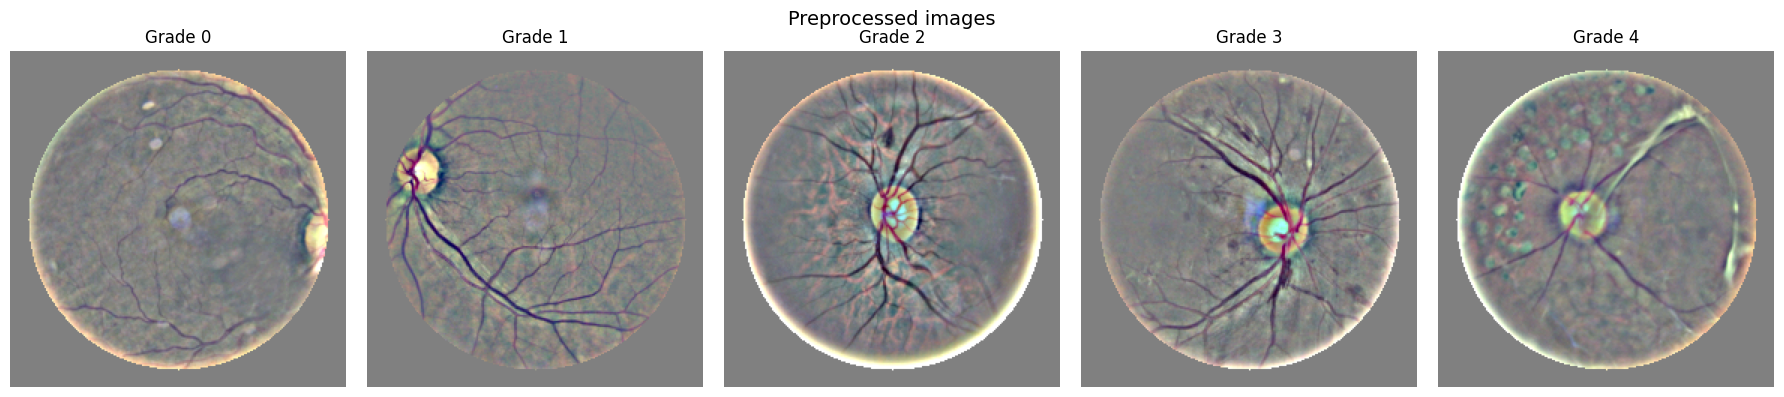

In [11]:
classes = np.unique(train_proc_labels.flatten())
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, cls in enumerate(classes):
    labels_flat = train_proc_labels.flatten()
    sample_idx = np.where(labels_flat == cls)[0][0]
    sample = np.squeeze(train_proc_imgs[sample_idx]).astype(np.uint8)

    axes[idx].imshow(sample)
    axes[idx].set_title(f"Grade {int(cls)}", fontsize=12)
    axes[idx].axis("off")

fig.suptitle("Preprocessed images", fontsize=14)
plt.tight_layout()
plt.show()

Per-channel statistics (preprocessed training set):
 Channel     Mean      Std    Min    Max
       R   130.81    19.77      0    255
       G   129.74    19.15      0    255
       B   129.03    11.60      0    255

Mean (normalized): [0.3095994 0.3095994 0.3095994]
Std  (normalized): [0.18229155 0.17564347 0.15563828]


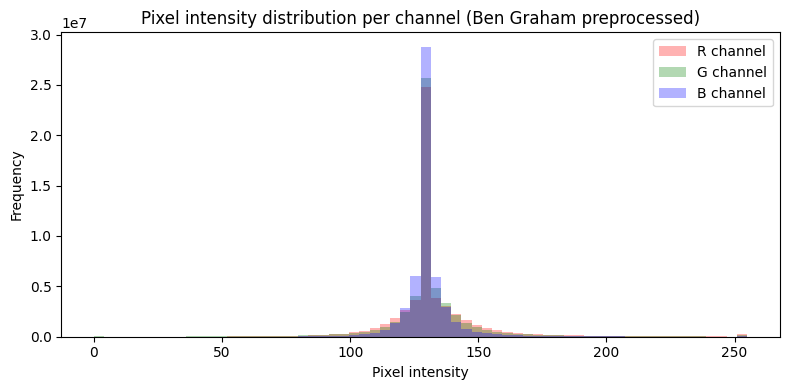

In [22]:
pixels = train_proc_imgs.reshape(-1, 3).astype(np.float32)

print("Per-channel statistics (preprocessed training set):")
print(f"{'Channel':>8} {'Mean':>8} {'Std':>8} {'Min':>6} {'Max':>6}")
for ch, name in enumerate(['R', 'G', 'B']):
    data = pixels[:, ch]
    print(f"{name:>8} {data.mean():>8.2f} {data.std():>8.2f} "
          f"{int(data.min()):>6} {int(data.max()):>6}")

pixels_normalized = pixels / 255.0 
mean = pixels_normalized.mean(axis=0)
std = pixels_normalized.std(axis=0)

print(f"\nMean (normalized): {mean}")
print(f"Std  (normalized): {std}")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['red', 'green', 'blue']
for ch, color in enumerate(colors):
    ax.hist(pixels[:, ch], bins=64, color=color, alpha=0.3,
            label=f'{["R","G","B"][ch]} channel')
ax.set_xlabel('Pixel intensity')
ax.set_ylabel('Frequency')
ax.set_title('Pixel intensity distribution per channel (Ben Graham preprocessed)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Data augmentation

To avoid the alteration of features that are clinically important for diagnosis, we apply only simple augmentations, such as **random horizontal and vertical flips**, and **random rotations**. We avoid augmentations that could change the appearance of lesions or other important features, involving colors, brightness, or contrast. We also avoid cropping or resizing that could remove important parts of the retina.

In [40]:
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomAffine(degrees=90, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.0, hue=0.0),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

eval_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std),
])

train_data = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "train"), transform=train_transforms)
val_data   = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "val"),   transform=eval_transforms)
test_data  = ImageFolder(root=os.path.join(PREPROCESSED_DIR, "test"),  transform=eval_transforms)

print(f"Train: {len(train_data)} samples, classes={train_data.classes}")
print(f"Val:   {len(val_data)} samples,   classes={val_data.classes}")
print(f"Test:  {len(test_data)} samples,  classes={test_data.classes}")

Train: 1080 samples, classes=['0', '1', '2', '3', '4']
Val:   120 samples,   classes=['0', '1', '2', '3', '4']
Test:  400 samples,  classes=['0', '1', '2', '3', '4']


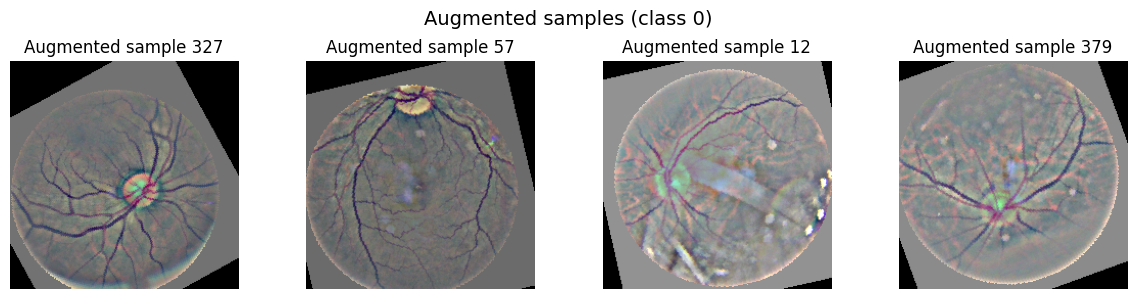

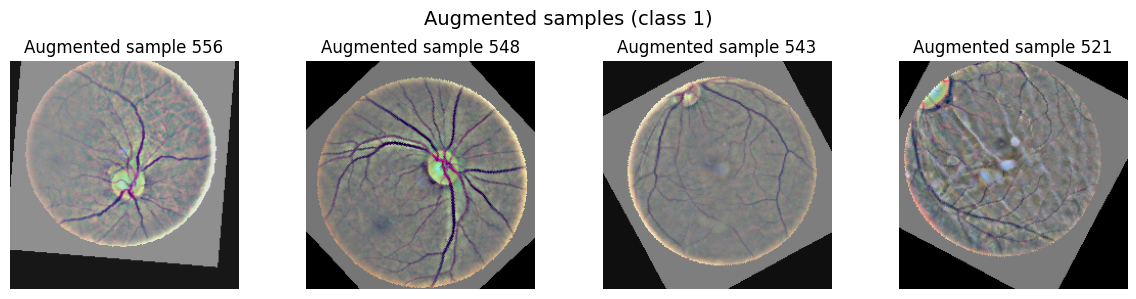

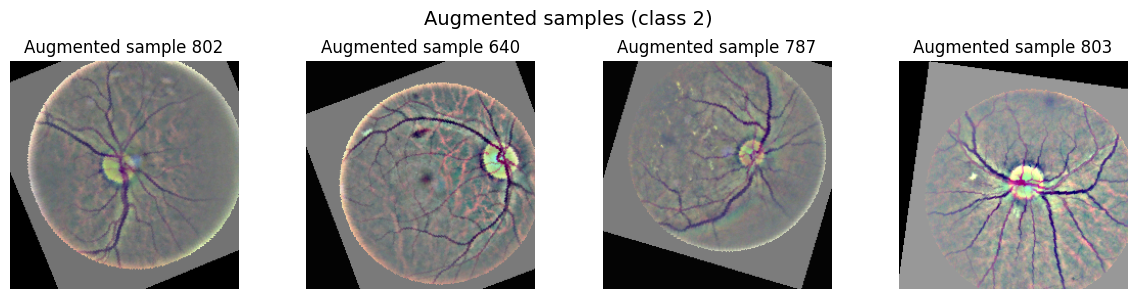

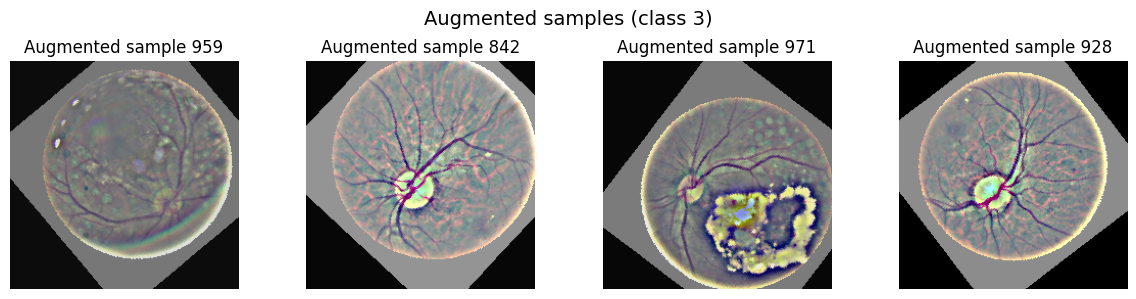

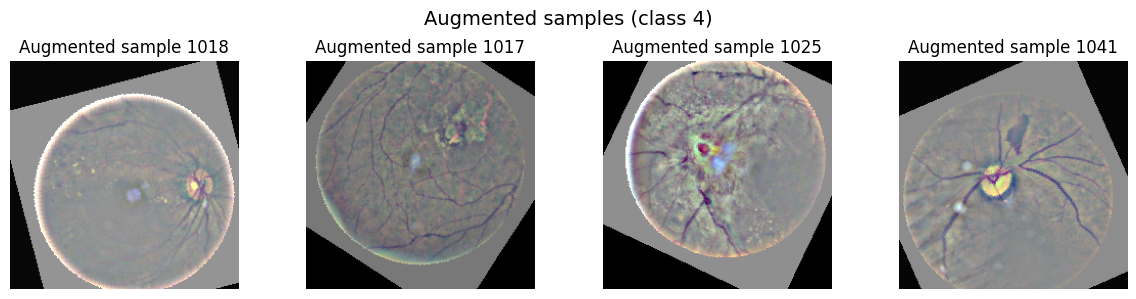

In [41]:

def plot_augmented_samples(dataset, class_idx, num_samples=4) -> None:
    """
    Plot augmented samples from the dataset for a specific class.

    Args:
        dataset (ImageFolder): The dataset containing the images.
        class_idx (int): The index of the class to visualize.
        num_samples (int): Number of augmented samples to display.
    """
    # Filter indices for the specified class
    class_indices = [i for i, (_, label) in enumerate(dataset.samples) if label == class_idx]
    
    # Randomly select indices for augmentation
    selected_indices = random.sample(class_indices, num_samples)
    
    plt.figure(figsize=(12, 3))
    
    for i, idx in enumerate(selected_indices):
        img, _ = dataset[idx]
        img = img.permute(1, 2, 0).numpy()  # Convert from CxHxW to HxWxC
        img = (img * std + mean) * 255.0  # Denormalize
        img = np.clip(img, 0, 255).astype(np.uint8)
        
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f'Augmented sample {selected_indices[i]}')
        plt.axis('off')
    
    plt.suptitle(f'Augmented samples (class {class_idx})', fontsize=14)
    plt.tight_layout()
    plt.show()

# Example usage: Plot augmented samples for class 4
plot_augmented_samples(train_data, class_idx=0, num_samples=4)
plot_augmented_samples(train_data, class_idx=1, num_samples=4)
plot_augmented_samples(train_data, class_idx=2, num_samples=4)
plot_augmented_samples(train_data, class_idx=3, num_samples=4)
plot_augmented_samples(train_data, class_idx=4, num_samples=4)

## 6. Model architecture

Ablation Study Techniques
- `frozen_backbone` (Frozen Backbone / Head Only): The model backbone (MobileNetV4) is frozen (requires_grad = False). Only the final classifier (classifier/head) is trained. This technique evaluates how well the features extracted by the pre-trained model perform on your specific domain.

- `partial_ft` (Partial Fine-Tuning / Backbone Tail Tuning): Most of the backbone weights are frozen, except for the last two layers (or the final convolutional block). This technique is used to refine high-level features to better adapt to the specificities of retinal images without risking catastrophic forgetting of the information learned on ImageNet.

- `full_ft` (Full Fine-Tuning / Full Training): All model parameters (backbone + classifier) are unfrozen (requires_grad = True). If the model is initialized with pre-trained weights, it is referred to as full fine-tuning; if the weights are initialized randomly (using pretrained=False), it is referred to as training from scratch.

In [ ]:
def get_model(num_classes=5, strategy='frozen_backbone', use_coral=False):
    """
    Create a MobileNetV4 model with the specified number of classes and training strategy.
    """
    pretrained = (strategy != 'full_ft')
    
    model = timm.create_model('mobilenetv4_conv_small.e2400_r224_in1k',  pretrained=pretrained,  num_classes=num_classes)
    
    if use_coral:
        in_features = model.classifier.in_features
        model.classifier = CoralLayer(size_in=in_features, num_classes=num_classes)
        
    return model.to(DEVICE)



def set_trainable_layers(model, strategy):
    # 1. Blocca tutto inizialmente
    for param in model.parameters():
        param.requires_grad = False
    
    # 2. Sblocca sempre il classificatore (che sia Lineare o Coral)
    for param in model.classifier.parameters():
        param.requires_grad = True
        
    # 3. Gestione logica Ablation
    if strategy == 'partial_ft':
        # Sblocca gli ultimi 2 layer del backbone
        # Nota: in MobileNetV4 i layer convoluzionali sono in model.features
        for param in list(model.features.parameters())[-2:]:
            param.requires_grad = True
            
    elif strategy == 'full_ft':
        # Sblocca to
        for param in model.parameters():
            param.requires_grad = True
            

def train_one_epoch(model, loader, optimizer, use_coral, num_classes=5):
    model.train()
    total_loss = 0
    for inputs, targets in tqdm(loader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE).long().view(-1)
        optimizer.zero_grad()
        
        logits = model(inputs)
        if use_coral:
            levels = levels_from_labelbatch(targets, num_classes=num_classes)
            loss = coral_loss(logits, levels.to(DEVICE))
        else:
            loss = nn.CrossEntropyLoss()(logits, targets)
            
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [43]:
model_coral = get_model(num_classes=len(classes), use_coral=False).to(DEVICE)
summary(model_coral, input_size=(1, 3, 224, 224), device=DEVICE)

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 5]                    --
├─Conv2d: 1-1                                      [1, 32, 112, 112]         864
├─BatchNormAct2d: 1-2                              [1, 32, 112, 112]         64
│    └─Identity: 2-1                               [1, 32, 112, 112]         --
│    └─ReLU: 2-2                                   [1, 32, 112, 112]         --
├─Sequential: 1-3                                  [1, 960, 7, 7]            --
│    └─Sequential: 2-3                             [1, 32, 56, 56]           --
│    │    └─ConvBnAct: 3-1                         [1, 32, 56, 56]           9,280
│    │    └─ConvBnAct: 3-2                         [1, 32, 56, 56]           1,088
│    └─Sequential: 2-4                             [1, 64, 28, 28]           --
│    │    └─ConvBnAct: 3-3                         [1, 96, 28, 28]           27,840
│    │    └─ConvBnAct: 3

In [44]:
model_coral = get_model(num_classes=len(classes), use_coral=True).to(DEVICE)
summary(model_coral, input_size=(1, 3, 224, 224), device=DEVICE)

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV3                                        [1, 4]                    --
├─Conv2d: 1-1                                      [1, 32, 112, 112]         864
├─BatchNormAct2d: 1-2                              [1, 32, 112, 112]         64
│    └─Identity: 2-1                               [1, 32, 112, 112]         --
│    └─ReLU: 2-2                                   [1, 32, 112, 112]         --
├─Sequential: 1-3                                  [1, 960, 7, 7]            --
│    └─Sequential: 2-3                             [1, 32, 56, 56]           --
│    │    └─ConvBnAct: 3-1                         [1, 32, 56, 56]           9,280
│    │    └─ConvBnAct: 3-2                         [1, 32, 56, 56]           1,088
│    └─Sequential: 2-4                             [1, 64, 28, 28]           --
│    │    └─ConvBnAct: 3-3                         [1, 96, 28, 28]           27,840
│    │    └─ConvBnAct: 3

## 7. Model training

Pay attention to weight initialization w.r.t. class imbalance.

In [45]:
def worker_init_fn(worker_id: int) -> None:
    """
    Seed each DataLoader worker deterministically based on its ID.
    
    Args:
        worker_id (int): The ID of the DataLoader worker.
    """
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)
    torch.manual_seed(SEED + worker_id)

# Set CUDA workspace config for deterministic cuBLAS operations in CUDA 12+
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

torch.use_deterministic_algorithms(True, warn_only=True)

GEN = torch.Generator()
GEN.manual_seed(SEED)

class FolderDataset(Dataset):
    """pytorch Dataset for fold splits: loads images by path with given transform."""
    def __init__(self, paths, targets, transform):
        self.paths = paths
        self.targets = targets
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        target = self.targets[idx]
        if self.transform:
            img = self.transform(img)
        return img, target


all_paths = [p for p, _ in train_data.imgs]
all_targets = np.array(train_data.targets)

### Frozen backbone: Cross-entropy loss with class weights

In [ ]:
set_seed(SEED)
GEN.manual_seed(SEED)

N_FOLDS = 5
EPOCHS = 50
BATCH_SIZE = 64
WARMUP_EPOCHS = 5
LR_MAX = 1e-3


strategy = 'frozen_backbone' 
use_coral = False           
num_classes = len(classes)

classes = np.unique(all_targets)
class_weights = compute_class_weight('balanced', classes=classes, y=all_targets)
w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", dict(zip(classes.tolist(), np.round(class_weights, 3))))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []


results = {}


for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_targets)), all_targets), 1):
    train_fold = FolderDataset([all_paths[i] for i in train_idx], all_targets[train_idx], train_transforms)
    val_fold   = FolderDataset([all_paths[i] for i in val_idx],   all_targets[val_idx],   eval_transforms)

    train_loader = DataLoader(train_fold, BATCH_SIZE, shuffle=True, worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
    val_loader   = DataLoader(val_fold,   BATCH_SIZE, shuffle=False,
                              worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
    print(f"Fold {fold}")
    model = get_model(num_classes=num_classes, strategy=strategy, use_coral=use_coral)

    set_trainable_layers(model, strategy)
    criterion = nn.CrossEntropyLoss(weight=w)
    val_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                              lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_auc, best_state, stale_epochs = 0.0, None, 0

    for epoch in range(1, EPOCHS + 1):
        if epoch <= WARMUP_EPOCHS:
            # Incremento lineare: da un valore vicino a 0 a LR_MAX
            current_lr = (LR_MAX / WARMUP_EPOCHS) * epoch
            for param_group in optimizer.param_groups:
                param_group['lr'] = current_lr
        else:
            # Dopo il warmup, lasciamo gestire lo step allo scheduler
            scheduler.step()
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                val_loss += val_criterion(logits, y).item()
                all_preds.extend(logits.argmax(dim=1).cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        val_loss /= len(val_loader)
        all_probs = np.concatenate(all_probs)

        acc = accuracy_score(all_labels, all_preds)
        qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
        f1 = f1_score(all_labels, all_preds, average='macro')

        if auc > best_auc:
            best_auc = auc
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1

        scheduler.step()

        if epoch == 1 or epoch % 5 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Acc: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

        if stale_epochs >= 10:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)

    model.eval()
    best_preds, best_labels, best_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            best_preds.extend(logits.argmax(dim=1).cpu().numpy())
            best_labels.extend(y.cpu().numpy())
            best_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    best_probs = np.concatenate(best_probs)
    best_acc_actual = accuracy_score(best_labels, best_preds)
    best_qwk = cohen_kappa_score(best_labels, best_preds, weights='quadratic')
    best_auc_actual = roc_auc_score(best_labels, best_probs, multi_class='ovr', average='macro')

    fold_results.append(best_acc_actual)
    print(f"  Fold {fold}: accuracy={best_acc_actual:.4f} qwk={best_qwk:.4f} auc={best_auc_actual:.4f}")

print(f"\nResults (CE, {N_FOLDS}-fold CV):")
print(f"  Accuracy: {np.mean(fold_results):.4f} +/- {np.std(fold_results):.4f}")

Class weights: {0: np.float64(0.444), 1: np.float64(1.688), 2: np.float64(1.049), 3: np.float64(1.113), 4: np.float64(3.273)}
Fold 1
  Epoch  1/50 | LR: 2.00e-04 | Train loss: 5.7437 | Val loss: 5.5500 | Acc: 0.1667 | QWK: -0.0589 | AUC: 0.4755
  Epoch  5/50 | LR: 9.91e-04 | Train loss: 5.0102 | Val loss: 5.0498 | Acc: 0.1481 | QWK: 0.0330 | AUC: 0.4908
  Epoch 10/50 | LR: 8.07e-04 | Train loss: 4.5385 | Val loss: 4.5772 | Acc: 0.1574 | QWK: 0.0554 | AUC: 0.5127
  Epoch 15/50 | LR: 5.08e-04 | Train loss: 4.2773 | Val loss: 4.3696 | Acc: 0.1713 | QWK: 0.0948 | AUC: 0.5327
  Epoch 20/50 | LR: 2.10e-04 | Train loss: 3.9224 | Val loss: 4.2738 | Acc: 0.1806 | QWK: 0.1071 | AUC: 0.5342
  Epoch 25/50 | LR: 2.58e-05 | Train loss: 3.4692 | Val loss: 4.1406 | Acc: 0.2037 | QWK: 0.1332 | AUC: 0.5430
  Epoch 30/50 | LR: 2.54e-05 | Train loss: 4.0643 | Val loss: 4.1546 | Acc: 0.1806 | QWK: 0.0784 | AUC: 0.5405
  Epoch 35/50 | LR: 2.07e-04 | Train loss: 3.8083 | Val loss: 4.1570 | Acc: 0.1806 | QWK:

: 

: 

Training final CE model on full training set
Class weights: {0: np.float64(0.444), 1: np.float64(1.688), 2: np.float64(1.049), 3: np.float64(1.113), 4: np.float64(3.273)}
  Epoch  1/50 | LR: 3.00e-04 | Train loss: 5.4351 | Val loss: 4.6850 | Acc: 0.2000 | QWK: -0.1008 | AUC: 0.5480
  Epoch  5/50 | LR: 2.93e-04 | Train loss: 5.1645 | Val loss: 4.5855 | Acc: 0.2500 | QWK: -0.1061 | AUC: 0.5582
  Epoch 10/50 | LR: 2.71e-04 | Train loss: 4.8543 | Val loss: 4.2593 | Acc: 0.2167 | QWK: -0.1051 | AUC: 0.5557
  Epoch 15/50 | LR: 2.38e-04 | Train loss: 4.3206 | Val loss: 4.1361 | Acc: 0.2417 | QWK: -0.0676 | AUC: 0.5722
  Epoch 20/50 | LR: 1.97e-04 | Train loss: 4.2155 | Val loss: 4.1080 | Acc: 0.2417 | QWK: -0.0536 | AUC: 0.5735
  Epoch 25/50 | LR: 1.50e-04 | Train loss: 3.8369 | Val loss: 3.9652 | Acc: 0.2500 | QWK: -0.0150 | AUC: 0.5700
  Epoch 30/50 | LR: 1.04e-04 | Train loss: 4.1254 | Val loss: 4.0971 | Acc: 0.2333 | QWK: -0.0742 | AUC: 0.5680
  Epoch 35/50 | LR: 6.26e-05 | Train loss: 3.

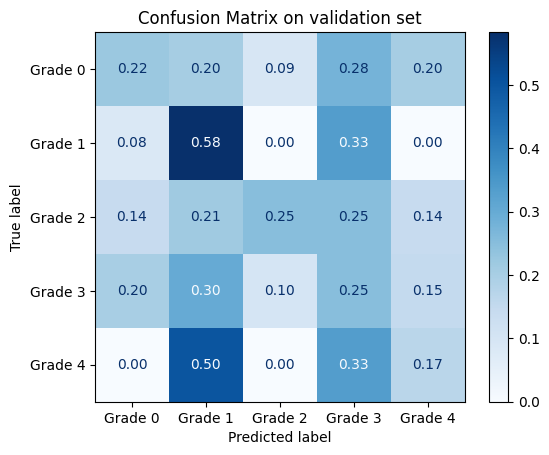

In [20]:
print("Training final CE model on full training set")

# Reset seeds for reproducibility on re-run
set_seed(SEED)
GEN.manual_seed(SEED)

EPOCHS = 50
BATCH_SIZE = 32

strategy = 'frozen_backbone' 
use_coral = False           
num_classes = len(classes)

classes = np.unique(all_targets)
class_weights = compute_class_weight('balanced', classes=classes, y=all_targets)
w = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print("Class weights:", dict(zip(classes.tolist(), np.round(class_weights, 3))))

final_loader = DataLoader(
    FolderDataset(all_paths, all_targets, train_transforms),
    batch_size=BATCH_SIZE, shuffle=True,
    worker_init_fn=worker_init_fn, num_workers=2,
    generator=GEN
)
val_loader  = DataLoader(val_data,  batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False,
                         worker_init_fn=worker_init_fn, num_workers=2, generator=GEN)

model_final = get_model(num_classes=num_classes, strategy=strategy, use_coral=use_coral)
set_trainable_layers(model_final, strategy)
criterion = nn.CrossEntropyLoss(weight=w)
val_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_final.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_auc, best_state, stale_epochs = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    model_final.train()
    train_loss = 0.0
    for x, y in final_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model_final(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(final_loader)

    model_final.eval()
    val_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model_final(x)
            val_loss += val_criterion(logits, y).item()
            all_preds.extend(logits.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    val_loss /= len(val_loader)
    all_probs = np.concatenate(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    qwk = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    if auc > best_auc:
        best_auc = auc
        best_state = copy.deepcopy(model_final.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1

    scheduler.step()

    if epoch == 1 or epoch % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"  Epoch {epoch:2d}/{EPOCHS} | LR: {lr_now:.2e} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Acc: {acc:.4f} | QWK: {qwk:.4f} | AUC: {auc:.4f}")

    if stale_epochs >= 10:
        print(f"  Early stopping at epoch {epoch}")
        break

model_final.load_state_dict(best_state)
model_final.eval()

val_preds, val_labels, val_probs = [], [], []
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model_final(x)
        val_preds.extend(logits.argmax(dim=1).cpu().numpy())
        val_labels.extend(y.cpu().numpy())
        val_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
val_probs = np.concatenate(val_probs)

print(f"\nValidation set results:")
print(f"  Macro F1:  {f1_score(val_labels, val_preds, average='macro'):.4f}")
print(f"  QWK:       {cohen_kappa_score(val_labels, val_preds, weights='quadratic'):.4f}")
print(f"  Accuracy:  {accuracy_score(val_labels, val_preds):.4f}")
print(f"  AUC:       {roc_auc_score(val_labels, val_probs, multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(val_labels, val_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"  Grade {cls}: precision={prec:.3f} recall={recall:.3f} F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix on validation set")
plt.show()

Test set results:
  Macro F1:  0.2401
  QWK:       0.0960
  Accuracy:  0.2550
  AUC:       0.6059

Per-class metrics:
  Grade 0: precision=0.284 recall=0.213 F1=0.243
  Grade 1: precision=0.274 recall=0.413 F1=0.330
  Grade 2: precision=0.282 recall=0.228 F1=0.252
  Grade 3: precision=0.271 recall=0.279 F1=0.275
  Grade 4: precision=0.332 recall=0.300 F1=0.315


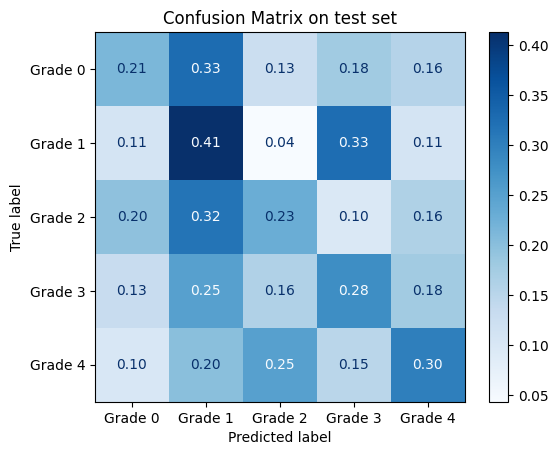

In [21]:
test_preds, test_labels, test_probs = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model_final(x)
        test_preds.extend(logits.argmax(dim=1).cpu().numpy())
        test_labels.extend(y.cpu().numpy())
        test_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
test_probs = np.concatenate(test_probs)

print(f"Test set results:")
print(f"  Macro F1:  {f1_score(test_labels, test_preds, average='macro'):.4f}")
print(f"  QWK:       {cohen_kappa_score(test_labels, test_preds, weights='quadratic'):.4f}")
print(f"  Accuracy:  {accuracy_score(test_labels, test_preds):.4f}")
print(f"  AUC:       {roc_auc_score(test_labels, test_probs, multi_class='ovr', average='macro'):.4f}")

cm = confusion_matrix(test_labels, test_preds, normalize='true')

print(f"\nPer-class metrics:")
for cls in range(5):
    recall = cm[cls, cls] / cm[cls].sum() if cm[cls].sum() > 0 else 0.0
    prec   = cm[:, cls][cls] / cm[:, cls].sum() if cm[:, cls].sum() > 0 else 0.0
    f1_c   = 2 * prec * recall / (prec + recall + 1e-8)
    print(f"  Grade {cls}: precision={prec:.3f} recall={recall:.3f} F1={f1_c:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'])
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.title("Confusion Matrix on test set")
plt.show()